In [78]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

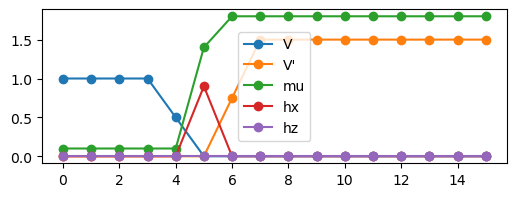

In [79]:
widthD = 5
widthF = 1
widthP = 10

X, Y = widthD+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.1

muD = 0.1 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

hx0 = 0.9 * t
hx = np.zeros_like(mu)
hx[widthD:widthD + widthF] = hx0

hz0 = 0 * t
hz = np.zeros_like(mu)
hz[:widthD] = hz0

U0 = 1 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 5.0 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hx, '-o', label='hx')
plt.plot(hz, '-o', label='hz')

plt.legend()

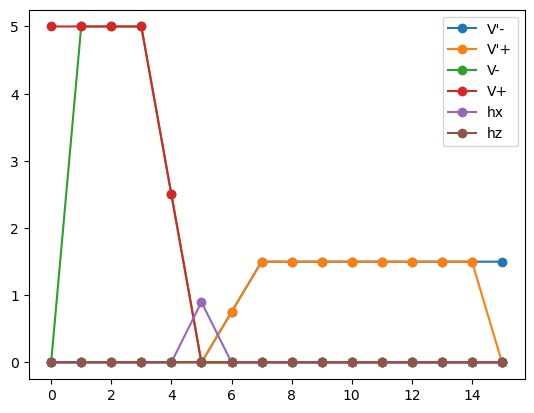

In [80]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(hx, '-o', label='hx')
plt.plot(hz, '-o', label='hz')
plt.legend()

In [81]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V, g_t=V,
                F_init=[0.3, 0.3, -0.3, -0.3],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=hx, hz=hz)

In [82]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=10000, temperature=T,verbose=True, mixing=0.5)

F0:
Absolute error: 0.010661941887834677
Relative error: 10661941887.834677
Average old: 0j
Average: (0.00019679337403248528+0j)
F_xplus:
Absolute error: 0.1324704991373434
Relative error: 20689399521.785812
Average old: (0.08+0j)
Average: (0.09714523769421525+0j)
F_xmin:
Absolute error: 0.057405786103337963
Relative error: 4038594581.6186876
Average old: (0.08+0j)
Average: (0.08596874000548321+0j)
F_yplus:
Absolute error: 0.08993869316637214
Relative error: 34863167906.06086
Average old: (-0.075+0j)
Average: (-0.08717761723584903-0.00019199581244800002j)
F_ymin:
Absolute error: 0.08993869316637214
Relative error: 34863167906.06086
Average old: (-0.075+0j)
Average: (-0.08717761723584903+0.00019199581244800002j)
Fuu_xplus:
Absolute error: 0.03357735627176691
Relative error: 26077798209.8669
Average old: (0.06+0j)
Average: (0.0637955751972246+0j)
Fuu_xmin:
Absolute error: 0.03665405856851419
Relative error: 12674743361.542513
Average old: (-0.06666666666666667+0j)
Average: (-0.0671380102

(array([-1.61598514e-01+1.36148023e-07j,  3.02422624e-02+6.95749668e-08j,
         1.30131762e-01-3.85015405e-07j,  1.70661541e-01-1.40974106e-06j,
         1.41362109e-01-2.21192273e-06j,  5.87512847e-02-7.67510503e-07j,
         7.32383158e-03-2.58254209e-07j, -4.78526438e-03-4.33273552e-07j,
         3.61859839e-04-5.50587147e-07j, -1.19680923e-03+5.26410533e-09j,
        -1.64534996e-04-2.49572191e-08j, -3.08845280e-04+1.27342781e-08j,
        -9.14382173e-05+3.90476313e-09j, -1.60447121e-04+9.67945978e-09j,
        -2.22357401e-05+2.71161226e-09j, -1.70364971e-04+1.12285761e-08j]),
 array([2.74393238e-01-1.02253772e-07j, 2.63086994e-01-3.13388862e-07j,
        2.61868607e-01-9.16876405e-07j, 2.60260649e-01-2.20557082e-06j,
        2.45819925e-01-3.69472100e-06j, 1.28489306e-01-2.85201148e-06j,
        1.12851269e-02-2.65034647e-07j, 6.75167401e-03-6.58699809e-07j,
        1.63601072e-03-3.90221381e-07j, 9.72553184e-04-1.40050501e-07j,
        5.83921835e-04-2.78058421e-08j, 1.9182

In [83]:
F, Fuu, Fdd = H.get_correlations()


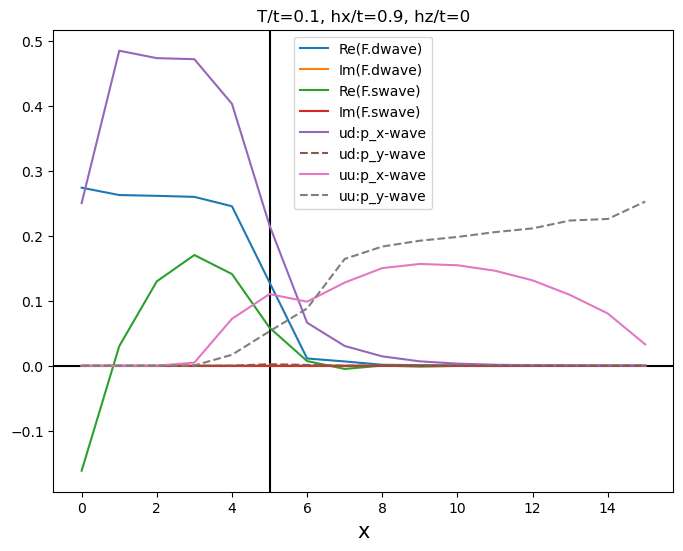

In [84]:
x = np.arange(0, widthD + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={hx0}, hz/t={hz0}")
axs.axhline(0, color = 'black')
axs.axvline(widthD, color='black', linestyle='-')
# axs.axvline(widthD, color='black', linestyle='--')
# axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.real(F.swave), label="Re(F.swave)")
axs.plot(x, np.imag(F.swave), label="Im(F.swave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

In [85]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True


In [86]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.6 + 1e-12, 0.002 )
])  # 164 temps total
print(len(temps))

205
